# Clasificar patrones de movimiento: _activo_, _pasivo_, _migración_

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import pickle
from warnings import filterwarnings
import seaborn as sns
import matplotlib.pyplot as plt

filterwarnings('ignore')

sns.set_style("white") 
sns.set_palette("pastel")
plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.figsize": (8, 4),
    "axes.edgecolor": "0.8",
})


In [3]:

df = pd.read_parquet("../data/processed/feature_dataset.parquet")
df.head()


,UniqueAnimalID,timestamp,mu_lat,mu_lon,se_mu_x,se_mu_y,adj_lat,adj_lon,prev_lat,prev_lon,...,season,x_proj,y_proj,prev_se_x,prev_se_y,bearing,prev_bearing,bearing_change,distance_per_day_real,movement_pattern
0,1,1986-07-01 18:00:00,69.7730,-141.3960,5835,5835,69.772693,-141.403451,NaN,NaN,...,verano,-2.199487e+06,246846.113968,NaN,NaN,NaN,NaN,0.000000,1.560623,estacionario
1,1,1986-07-02 00:00:00,69.7738,-141.3834,2517,2517,69.773429,-141.388987,69.772693,-141.403451,...,verano,-2.199467e+06,246281.720783,5835.0,5835.0,154.841241,NaN,0.000000,7.640792,estacionario
2,1,1986-07-02 06:00:00,69.7736,-141.3448,5323,5323,69.764930,-141.331186,69.773429,-141.388987,...,verano,-2.200658e+06,244167.346190,2517.0,2517.0,148.477694,154.841241,6.363548,7.640792,estacionario
3,1,1986-07-02 12:00:00,69.7727,-141.2902,8840,8840,69.783728,-141.265125,69.764930,-141.331186,...,verano,-2.198852e+06,241400.844917,5323.0,5323.0,176.425859,148.477694,27.948165,7.640792,estacionario
4,1,1986-07-02 18:00:00,69.7717,-141.2289,11637,11637,69.778055,-141.296034,69.783728,-141.265125,...,verano,-2.199351e+06,242656.504996,8840.0,8840.0,157.258475,176.425859,19.167384,7.640792,estacionario


In [18]:
df.season.unique()

array(['verano', 'transicion', 'invierno'], dtype=object)

In [4]:
df.movement_pattern.unique()

array(['estacionario', 'activo'], dtype=object)

In [6]:
df.movement_pattern.value_counts()

movement_pattern
estacionario    220663
activo           73552
Name: count, dtype: int64

In [7]:
num_cols = ["velocity_kmh","bearing_change","acceleration_kmph2",
            "daylight_hours","AvgLatitude","AvgLongitude"]
df = pd.get_dummies(df[num_cols + ["season","movement_pattern"]], drop_first=True).dropna()
df.head()

,velocity_kmh,bearing_change,acceleration_kmph2,daylight_hours,AvgLatitude,AvgLongitude,season_transicion,season_verano,movement_pattern_estacionario
0,0.260104,0.000000,-0.072161,24.0,70.256209,-143.788483,False,True,True
1,0.094055,0.000000,-0.027675,24.0,70.256209,-143.788483,False,True,True
2,0.404117,6.363548,0.051677,24.0,70.256209,-143.788483,False,True,True
3,0.550249,27.948165,0.024355,24.0,70.256209,-143.788483,False,True,True
4,0.225044,19.167384,-0.054201,24.0,70.256209,-143.788483,False,True,True


In [15]:

X = df.drop(columns=["movement_pattern_estacionario"])   # target dummy 0/1
y = df["movement_pattern_estacionario"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=500, class_weight='balanced')  #  
                            
logreg.fit(X_train_sc, y_train)

print(classification_report(y_test, logreg.predict(X_test_sc)))
print("AUC:", roc_auc_score(y_test, logreg.predict_proba(X_test_sc)[:,1]))

# Guardar
pickle.dump(logreg, open("../models/cls_pattern.pkl","wb"))
pickle.dump(scaler,  open("../models/cls_scaler.pkl","wb"))


              precision    recall  f1-score   support

       False       0.66      0.84      0.74     22066
        True       0.94      0.86      0.90     66199

    accuracy                           0.85     88265
   macro avg       0.80      0.85      0.82     88265
weighted avg       0.87      0.85      0.86     88265

AUC: 0.9221610788387142


1a vuelta:

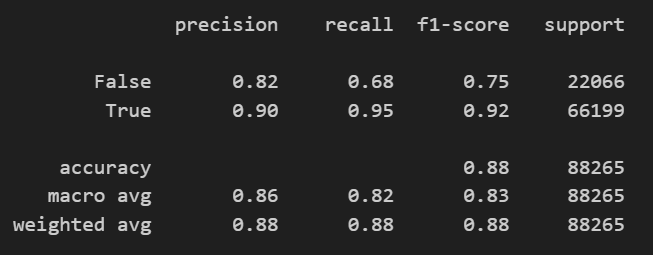

* Resumen General

    Precisión global (accuracy): 88% — El modelo acierta el 88% de las veces.

    AUC (Área Bajo la Curva ROC): 0.92 — Excelente. Indica una gran capacidad del modelo para distinguir entre las clases True y False.

* Métricas por Clase
Clase: False

    Precisión (precision): 0.82 — El 82% de las veces que el modelo predice False, acierta.

    Exhaustividad (recall): 0.68 — El modelo solo identifica correctamente el 68% de los casos realmente False. Algo bajo.

    F1-score: 0.75 — Balance moderado entre precisión y recall. Puede mejorarse.

Clase: True

    Precisión: 0.90 — Muy buena. El 90% de las predicciones de True son correctas.

    Recall: 0.95 — Excelente. El modelo detecta el 95% de los casos realmente True.

    F1-score: 0.92 — Rendimiento muy alto para esta clase.



2.               precision    recall  f1-score   support

       False       0.66      0.84      0.74     22066
        True       0.94      0.86      0.90     66199

    accuracy                           0.85     88265
   macro avg       0.80      0.85      0.82     88265
weighted avg       0.87      0.85      0.86     88265

AUC: 0.9221610788387142

2a vuelta:

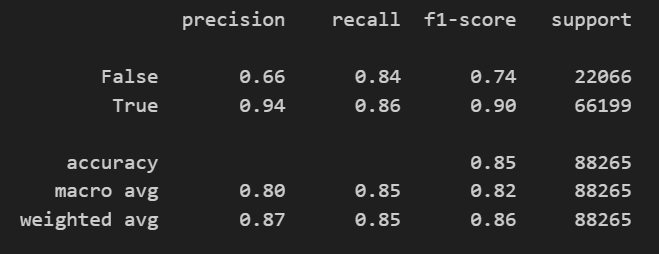

     recall MEJORADO en la clase False de 0.68 a 0.84, lo cual era tu prioridad.

    El costo fue:

        Menor precisión en False (más falsos positivos).

        Ligera caída en accuracy y F1-score general.

    Esto es típico cuando haces un trade-off recall vs precisión, especialmente con clases desbalanceadas.

3a. prueba

              precision    recall  f1-score   support

      activo       0.66      0.84      0.74     22066
estacionario       0.94      0.86      0.90     66199

    accuracy                           0.85     88265
   macro avg       0.80      0.85      0.82     88265
weighted avg       0.87      0.85      0.86     88265

ROC AUC: 0.9221589292538019
AUC media (5-fold): 0.9223960299442613


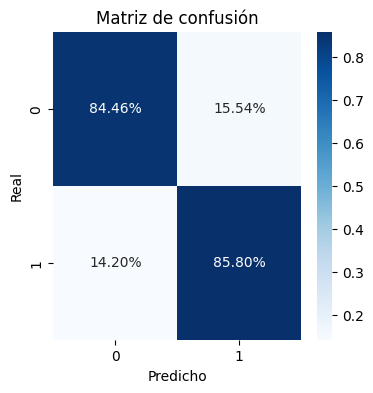

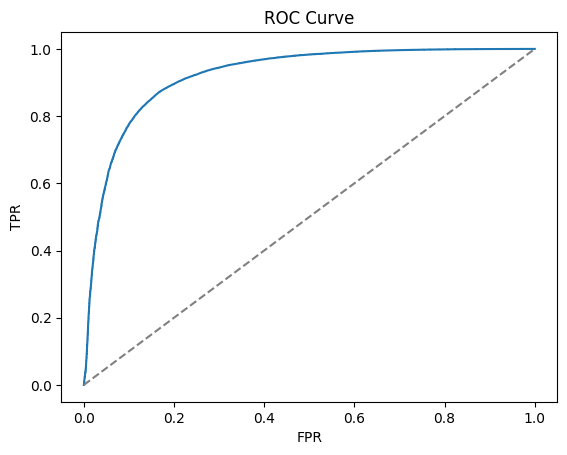

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Carga tu dataset (ajusta la ruta)
df = pd.read_parquet("../data/processed/feature_dataset.parquet")

# Convierte movement_pattern a binario
df["movement_pattern_bin"] = (df["movement_pattern"] == "estacionario").astype(int)

# Define tus features (numéricas, sin incluir movement_pattern)
features = [
    "velocity_kmh", "bearing_change", "acceleration_kmph2",
    "daylight_hours", "AvgLatitude", "AvgLongitude",
    "season_verano", "season_transicion"
]
# Convierte 'season' en dummies (sólo una vez, al cargar el dataset)
dummies = pd.get_dummies(df["season"], prefix="season")
for col in ["season_verano", "season_transicion"]:
    if col not in dummies.columns:
        dummies[col] = 0  # Si falta, ponla a cero (por si algún valor no existe)
df = pd.concat([df, dummies], axis=1)


X = df[features].dropna()
y = df.loc[X.index, "movement_pattern_bin"]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=10
)

# Modelo base (class_weight='balanced')
logreg = LogisticRegression(class_weight='balanced', max_iter=300)
logreg.fit(X_train, y_train)

# Evaluación en test
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["activo", "estacionario"]))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

# Validación cruzada (AUC media)
auc_cv = cross_val_score(
    logreg, X, y, cv=5, scoring='roc_auc'
)
print("AUC media (5-fold):", auc_cv.mean())

# Matriz de confusión
plt.figure(figsize=(4, 4))
sns.heatmap(confusion_matrix(y_test, y_pred, normalize='true'), annot=True, 
            fmt='.2%', cmap='Blues')
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

# ROC curve opcional
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()


    Nuestro modelo de clasificación identifica correctamente los patrones de movimiento (activo vs. estacionario) de los osos polares con una precisión global del 85%. Destaca especialmente en la identificación de osos estacionarios (f1-score 0.90), y a pesar del desbalance, mantiene un buen rendimiento con los osos activos (f1-score 0.74, recall 0.84).”

    ¿El modelo es útil para detectar osos activos?
    Sí, identifica 8 de cada 10 osos activos correctamente.

    ¿El modelo está sesgado hacia la clase mayoritaria?
    No, gracias al uso de class_weight='balanced' y las buenas métricas de ambas clases.

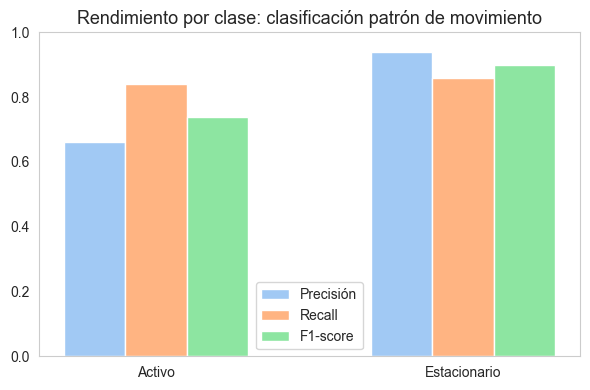

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Valores ejemplo (puedes poner los tuyos)
clases = ["Activo", "Estacionario"]
f1 = [0.74, 0.90]
precision = [0.66, 0.94]
recall = [0.84, 0.86]

bar_width = 0.2
x = np.arange(len(clases))

plt.figure(figsize=(6,4))
plt.bar(x-bar_width, precision, bar_width, label="Precisión")
plt.bar(x, recall, bar_width, label="Recall")
plt.bar(x+bar_width, f1, bar_width, label="F1-score")

plt.xticks(x, clases)
plt.ylim(0, 1)
plt.legend()
plt.title("Rendimiento por clase: clasificación patrón de movimiento")
plt.tight_layout()
plt.show()
